Model Development
## Dialect & Code-Switching Detector | NLP Semester Project

This notebook trains a **token-level language identification model** using multilingual BERT (mBERT).  
Given a sentence of Pakistani code-switched text, the model predicts the language of each token:
- `URDU` — Roman Urdu or pure Urdu word
- `ENGLISH` — English word

**Pipeline:**
1. Load and explore the dataset
2. Prepare token-level labels
3. Tokenize with mBERT tokenizer
4. Train a Token Classification model
5. Evaluate with accuracy, F1, confusion matrix
6. Save model for deployment

## Step 1 — Install Dependencies

In [1]:
%pip install transformers accelerate seqeval openpyxl scikit-learn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Load Dataset

In [2]:
import pandas as pd
import numpy as np

df = pd.read_excel('nlp_dataset_final.xlsx')
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head(10)

Dataset shape: (750, 8)
Columns: ['sr_no', 'id', 'sentence', 'language_type', 'tokens', 'token_labels', 'num_tokens', 'domain']


,sr_no,id,sentence,language_type,tokens,token_labels,num_tokens,domain
0,1,ID_742_8161,She was not in class again today I noticed,ENGLISH,She | was | not | in | class | again | today |...,ENGLISH | ENGLISH | ENGLISH | ENGLISH | URDU |...,9,social
1,2,ID_223_1472,tum ne dekha kya wo new movie,CODE_MIX,tum | ne | dekha | kya | wo | new | movie,URDU | URDU | URDU | URDU | URDU | URDU | URDU,7,social
2,3,ID_20_3851,yaar aaj match dekhne ja raha hoon,CODE_MIX,yaar | aaj | match | dekhne | ja | raha | hoon,URDU | URDU | URDU | URDU | URDU | URDU | URDU,7,technology
3,4,ID_57_3267,yaar I am so tired aaj,CODE_MIX,yaar | I | am | so | tired | aaj,URDU | ENGLISH | ENGLISH | URDU | ENGLISH | URDU,6,social
4,5,ID_718_7112,I just need to review a few more pages tonight,ENGLISH,I | just | need | to | review | a | few | more...,ENGLISH | ENGLISH | ENGLISH | ENGLISH | URDU |...,10,entertainment
5,6,ID_710_9777,I think our group did really well on this,ENGLISH,I | think | our | group | did | really | well ...,ENGLISH | ENGLISH | ENGLISH | URDU | ENGLISH |...,9,technology
6,7,ID_484_3730,tum ne paper kaise diya aaj,ROMAN_URDU,tum | ne | paper | kaise | diya | aaj,URDU | URDU | URDU | URDU | URDU | URDU,6,entertainment
7,8,ID_126_6576,main just bata raha tha ke meri baat suno,CODE_MIX,main | just | bata | raha | tha | ke | meri | ...,URDU | ENGLISH | URDU | URDU | URDU | URDU | U...,9,technology
8,9,ID_561_3198,She explained the concept very clearly today,ENGLISH,She | explained | the | concept | very | clear...,ENGLISH | ENGLISH | URDU | URDU | ENGLISH | UR...,7,entertainment
9,10,ID_196_6280,yaar assignment mein kuch nahi samjha mujhe,CODE_MIX,yaar | assignment | mein | kuch | nahi | samjh...,URDU | URDU | URDU | URDU | URDU | URDU | URDU,7,technology


Matplotlib is building the font cache; this may take a moment.


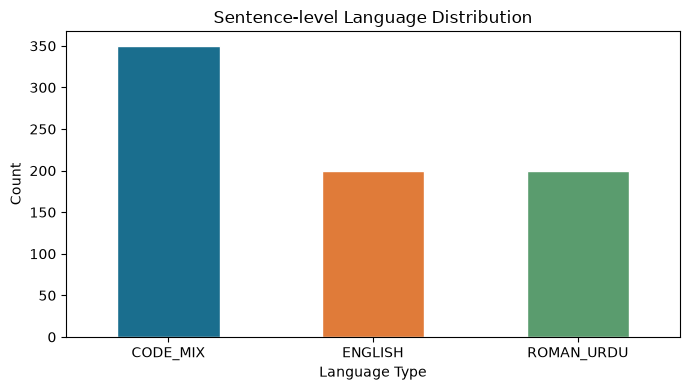

language_type
CODE_MIX      350
ENGLISH       200
ROMAN_URDU    200
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt

# Distribution of sentence-level language types
lang_counts = df['language_type'].value_counts()
plt.figure(figsize=(7, 4))
lang_counts.plot(kind='bar', color=['#1a6e8e', '#e07b39', '#5a9c6e'], edgecolor='white')
plt.title('Sentence-level Language Distribution')
plt.xlabel('Language Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(lang_counts)

## Step 3 — Prepare Token-Level Data

In [4]:
# Each row has: sentence, tokens (pipe-separated), token_labels (pipe-separated)
# We parse them into aligned (token, label) lists

label2id = {'URDU': 0, 'ENGLISH': 1}
id2label = {0: 'URDU', 1: 'ENGLISH'}

sentences_tokens = []
sentences_labels = []

for _, row in df.iterrows():
    tokens = [t.strip() for t in str(row['tokens']).split('|')]
    labels = [l.strip() for l in str(row['token_labels']).split('|')]
    
    # Align lengths (safety check)
    min_len = min(len(tokens), len(labels))
    sentences_tokens.append(tokens[:min_len])
    sentences_labels.append([label2id.get(l, 0) for l in labels[:min_len]])

print(f'Total sentences: {len(sentences_tokens)}')
print(f'Example tokens : {sentences_tokens[0]}')
print(f'Example labels : {sentences_labels[0]}')
print(f'Decoded labels : {[id2label[l] for l in sentences_labels[0]]}')

Total sentences: 750
Example tokens : ['She', 'was', 'not', 'in', 'class', 'again', 'today', 'I', 'noticed']
Example labels : [1, 1, 1, 1, 0, 0, 1, 1, 0]
Decoded labels : ['ENGLISH', 'ENGLISH', 'ENGLISH', 'ENGLISH', 'URDU', 'URDU', 'ENGLISH', 'ENGLISH', 'URDU']


Total tokens : 5391
URDU tokens  : 4244 (78.7%)
ENGLISH tokens: 1147 (21.3%)


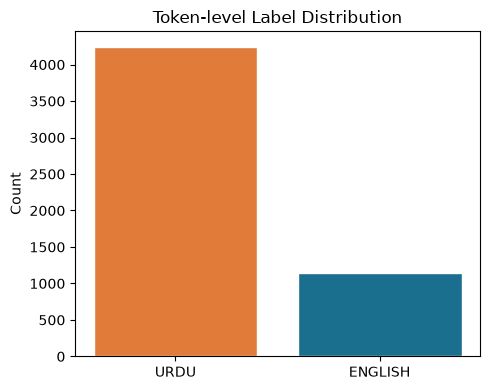

In [5]:
# Count token-level label distribution
all_labels = [l for sent in sentences_labels for l in sent]
urdu_count = all_labels.count(0)
eng_count  = all_labels.count(1)
total      = len(all_labels)

print(f'Total tokens : {total}')
print(f'URDU tokens  : {urdu_count} ({urdu_count/total*100:.1f}%)')
print(f'ENGLISH tokens: {eng_count} ({eng_count/total*100:.1f}%)')

plt.figure(figsize=(5, 4))
plt.bar(['URDU', 'ENGLISH'], [urdu_count, eng_count], color=['#e07b39', '#1a6e8e'], edgecolor='white')
plt.title('Token-level Label Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 4 — Train / Test Split

In [6]:
from sklearn.model_selection import train_test_split

train_tokens, test_tokens, train_labels, test_labels = train_test_split(
    sentences_tokens, sentences_labels,
    test_size=0.2,
    random_state=42
)

print(f'Training sentences : {len(train_tokens)}')
print(f'Testing sentences  : {len(test_tokens)}')

Training sentences : 600
Testing sentences  : 150


## Step 5 — Tokenize with mBERT

In [7]:
from transformers import AutoTokenizer

MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

print('Tokenizer loaded:', MODEL_NAME)
print('Vocabulary size :', tokenizer.vocab_size)

d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\farah\.cache\huggingface\hub\models--bert-base-multilingual-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administ

Tokenizer loaded: bert-base-multilingual-cased
Vocabulary size : 119547


In [8]:
def tokenize_and_align_labels(token_lists, label_lists, tokenizer, max_length=128):
    """
    mBERT uses WordPiece — one word may become multiple sub-tokens.
    We assign the label to the FIRST sub-token of each word,
    and -100 to all continuation sub-tokens (ignored by loss).
    """
    all_input_ids, all_attention_masks, all_label_ids = [], [], []

    for tokens, labels in zip(token_lists, label_lists):
        encoding = tokenizer(
            tokens,
            is_split_into_words=True,
            padding='max_length',
            truncation=True,
            max_length=max_length
        )

        word_ids  = encoding.word_ids()
        label_ids = []
        prev_word = None

        for wid in word_ids:
            if wid is None:
                label_ids.append(-100)          # [CLS], [SEP], [PAD]
            elif wid != prev_word:
                label_ids.append(labels[wid])   # First sub-token → real label
            else:
                label_ids.append(-100)           # Continuation sub-token → ignore
            prev_word = wid

        all_input_ids.append(encoding['input_ids'])
        all_attention_masks.append(encoding['attention_mask'])
        all_label_ids.append(label_ids)

    return all_input_ids, all_attention_masks, all_label_ids


train_ids, train_masks, train_lbl = tokenize_and_align_labels(train_tokens, train_labels, tokenizer)
test_ids,  test_masks,  test_lbl  = tokenize_and_align_labels(test_tokens,  test_labels,  tokenizer)

print('Tokenization complete.')
print('Example input_ids (first 15):', train_ids[0][:15])
print('Example label_ids (first 15):', train_lbl[0][:15])

Tokenization complete.
Example input_ids (first 15): [101, 12126, 108440, 10113, 179, 10921, 11163, 28335, 10213, 13173, 10263, 77586, 18220, 102, 0]
Example label_ids (first 15): [-100, 0, 0, -100, 0, -100, 0, 0, -100, 0, -100, 0, -100, -100, -100]


## Step 6 — Build PyTorch Dataset

In [9]:
import torch

class LangTagDataset(torch.utils.data.Dataset):
    """PyTorch Dataset for token-level language identification."""

    def __init__(self, input_ids, attention_masks, label_ids):
        self.input_ids       = input_ids
        self.attention_masks = attention_masks
        self.label_ids       = label_ids

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids'      : torch.tensor(self.input_ids[idx],       dtype=torch.long),
            'attention_mask' : torch.tensor(self.attention_masks[idx],  dtype=torch.long),
            'labels'         : torch.tensor(self.label_ids[idx],        dtype=torch.long),
        }

train_dataset = LangTagDataset(train_ids, train_masks, train_lbl)
test_dataset  = LangTagDataset(test_ids,  test_masks,  test_lbl)

print(f'Train dataset size : {len(train_dataset)}')
print(f'Test  dataset size : {len(test_dataset)}')

Train dataset size : 600
Test  dataset size : 150


## Step 7 — Load mBERT for Token Classification

In [10]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,          # URDU=0, ENGLISH=1
    id2label=id2label,
    label2id=label2id
)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1784.27it/s]
[transformers] BertForTokenClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/archi

Total parameters    : 177,264,386
Trainable parameters: 177,264,386


## Step 8 — Define Metrics

In [11]:
import numpy as np
from seqeval.metrics import f1_score, classification_report

def compute_metrics(eval_pred):
    """Compute token-level F1 ignoring -100 padding positions."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=2)

    true_preds, true_labels = [], []

    for pred_row, label_row in zip(predictions, labels):
        p_seq, l_seq = [], []
        for p, l in zip(pred_row, label_row):
            if l != -100:             # Skip padding
                p_seq.append(id2label[p])
                l_seq.append(id2label[l])
        true_preds.append(p_seq)
        true_labels.append(l_seq)

    f1  = f1_score(true_labels, true_preds, average='weighted')
    return {'f1': round(f1, 4)}

print('Metric function defined: weighted F1 on token predictions')

Metric function defined: weighted F1 on token predictions


## Step 9 — Training

In [12]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir             = './lang_detect_model',
    num_train_epochs       = 4,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 16,
    learning_rate          = 3e-5,
    weight_decay           = 0.01,
    eval_strategy          = 'epoch',
    save_strategy          = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model  = 'f1',
    logging_steps          = 20,
    report_to              = 'none'
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics
)

print('Trainer ready. Starting training...')
trainer.train()

Trainer ready. Starting training...


d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,0.294075,0.121376,0.854500
2,0.088776,0.044121,0.944400
3,0.026764,0.027873,0.973200
4,0.016525,0.020844,0.979300


d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: URDU seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ENGLISH seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.08s/it]
d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: URDU seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
d:\Projects\Dialect-Code-Switching-Detector\ve

TrainOutput(global_step=152, training_loss=0.08791680531086106, metrics={'train_runtime': 3132.2574, 'train_samples_per_second': 0.766, 'train_steps_per_second': 0.049, 'total_flos': 156778054041600.0, 'train_loss': 0.08791680531086106, 'epoch': 4.0})

## Step 10 — Evaluate

In [13]:
results = trainer.evaluate()
print('\n=== Evaluation Results ===')
for k, v in results.items():
    print(f'  {k:35s}: {v}')

d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: URDU seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
d:\Projects\Dialect-Code-Switching-Detector\venv\Lib\site-packages\seqeval\metrics\sequence_labeling.py:171: UserWarning: ENGLISH seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


Training Loss,Validation Loss,Epoch,F1
0.016525,0.020844,4,0.979300



=== Evaluation Results ===
  eval_loss                          : 0.020843809470534325
  eval_f1                            : 0.9793


Classification Report:
              precision    recall  f1-score   support

        URDU       1.00      1.00      1.00       888
     ENGLISH       0.99      0.98      0.98       191

    accuracy                           0.99      1079
   macro avg       0.99      0.99      0.99      1079
weighted avg       0.99      0.99      0.99      1079



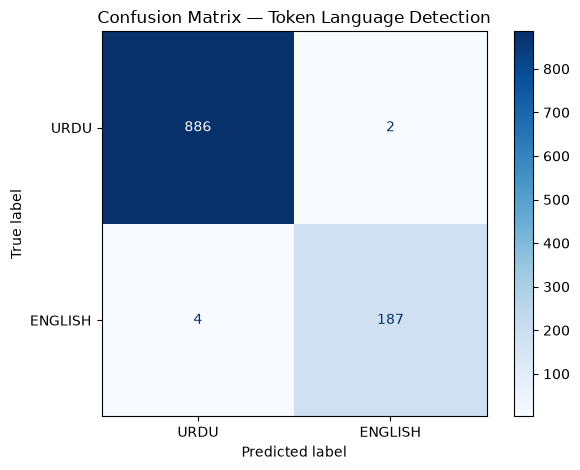

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Get all predictions
preds_output = trainer.predict(test_dataset)
pred_ids     = np.argmax(preds_output.predictions, axis=2)
true_ids     = preds_output.label_ids

# Flatten — ignore -100 positions
flat_preds, flat_true = [], []
for p_row, l_row in zip(pred_ids, true_ids):
    for p, l in zip(p_row, l_row):
        if l != -100:
            flat_preds.append(p)
            flat_true.append(l)

print('Classification Report:')
print(classification_report(flat_true, flat_preds, target_names=['URDU', 'ENGLISH']))

cm = confusion_matrix(flat_true, flat_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['URDU', 'ENGLISH'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Token Language Detection')
plt.tight_layout()
plt.show()

## Step 11 — Inference Demo

In [15]:
def predict_sentence(sentence, model, tokenizer, id2label):
    """Predict language tag for each word in a sentence."""
    words    = sentence.split()
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors='pt',
        truncation=True,
        max_length=128
    )

    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)

    predictions = torch.argmax(outputs.logits, dim=2)[0].tolist()
    word_ids    = encoding.word_ids()

    results, seen = [], set()
    for idx, wid in enumerate(word_ids):
        if wid is not None and wid not in seen:
            results.append((words[wid], id2label[predictions[idx]]))
            seen.add(wid)

    return results


# Test on sample sentences
test_sentences = [
    "yaar I am so tired aaj",
    "bro this project bohot zyada kaam hai",
    "I have no idea what happened in class today",
    "aaj ka lecture honestly boring tha",
    "hum log basically wait kar rahe hain result ka",
]

for sent in test_sentences:
    tags = predict_sentence(sent, model, tokenizer, id2label)
    print(f'\nInput   : {sent}')
    print(f'Tags    : {tags}')
    lang_counts = {}
    for _, tag in tags:
        lang_counts[tag] = lang_counts.get(tag, 0) + 1
    dominant = max(lang_counts, key=lang_counts.get)
    print(f'Dominant: {dominant} ({lang_counts})')


Input   : yaar I am so tired aaj
Tags    : [('yaar', 'URDU'), ('I', 'ENGLISH'), ('am', 'ENGLISH'), ('so', 'URDU'), ('tired', 'ENGLISH'), ('aaj', 'URDU')]
Dominant: URDU ({'URDU': 3, 'ENGLISH': 3})

Input   : bro this project bohot zyada kaam hai
Tags    : [('bro', 'URDU'), ('this', 'ENGLISH'), ('project', 'URDU'), ('bohot', 'URDU'), ('zyada', 'URDU'), ('kaam', 'URDU'), ('hai', 'URDU')]
Dominant: URDU ({'URDU': 6, 'ENGLISH': 1})

Input   : I have no idea what happened in class today
Tags    : [('I', 'ENGLISH'), ('have', 'ENGLISH'), ('no', 'ENGLISH'), ('idea', 'ENGLISH'), ('what', 'ENGLISH'), ('happened', 'URDU'), ('in', 'ENGLISH'), ('class', 'URDU'), ('today', 'ENGLISH')]
Dominant: ENGLISH ({'ENGLISH': 7, 'URDU': 2})

Input   : aaj ka lecture honestly boring tha
Tags    : [('aaj', 'URDU'), ('ka', 'URDU'), ('lecture', 'URDU'), ('honestly', 'URDU'), ('boring', 'URDU'), ('tha', 'URDU')]
Dominant: URDU ({'URDU': 6})

Input   : hum log basically wait kar rahe hain result ka
Tags    : [('hum

## Step 12 — Save Model

In [16]:
model.save_pretrained('./lang_detect_model_final')
tokenizer.save_pretrained('./lang_detect_model_final')
print('Model and tokenizer saved to ./lang_detect_model_final')
print('Use AutoModelForTokenClassification.from_pretrained() to reload.')

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.67s/it]

Model and tokenizer saved to ./lang_detect_model_final
Use AutoModelForTokenClassification.from_pretrained() to reload.
